## Import of Libraries

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
import pandas as pd
import seaborn as sns
import plotly.express as px

from sklearn.decomposition import PCA



## Initial Study of Dataset

In [2]:
X,y = load_digits(return_X_y=True)

In [3]:
X.shape,y.shape

((1797, 64), (1797,))

We can visualize the images by resizing them to a square matrix

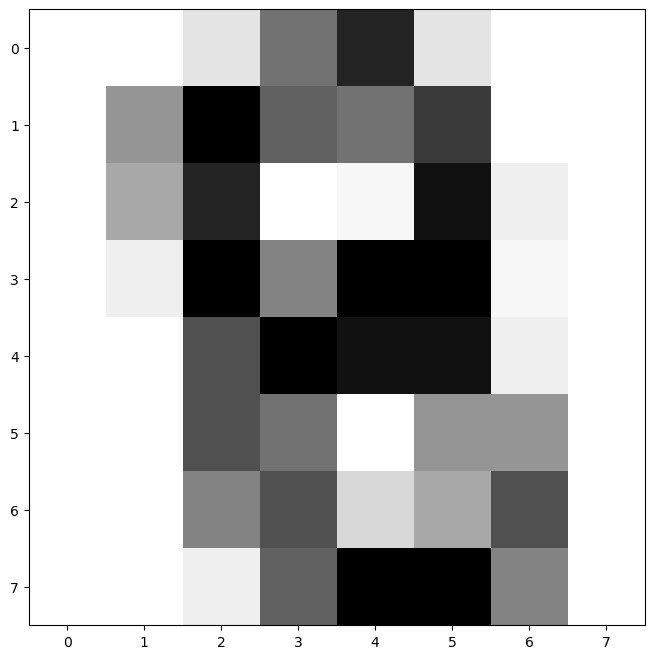

In [4]:
plt.figure(figsize=(8,8))
plt.imshow(X[500].reshape(8,8),cmap='Greys')

In [5]:
y[500]

8

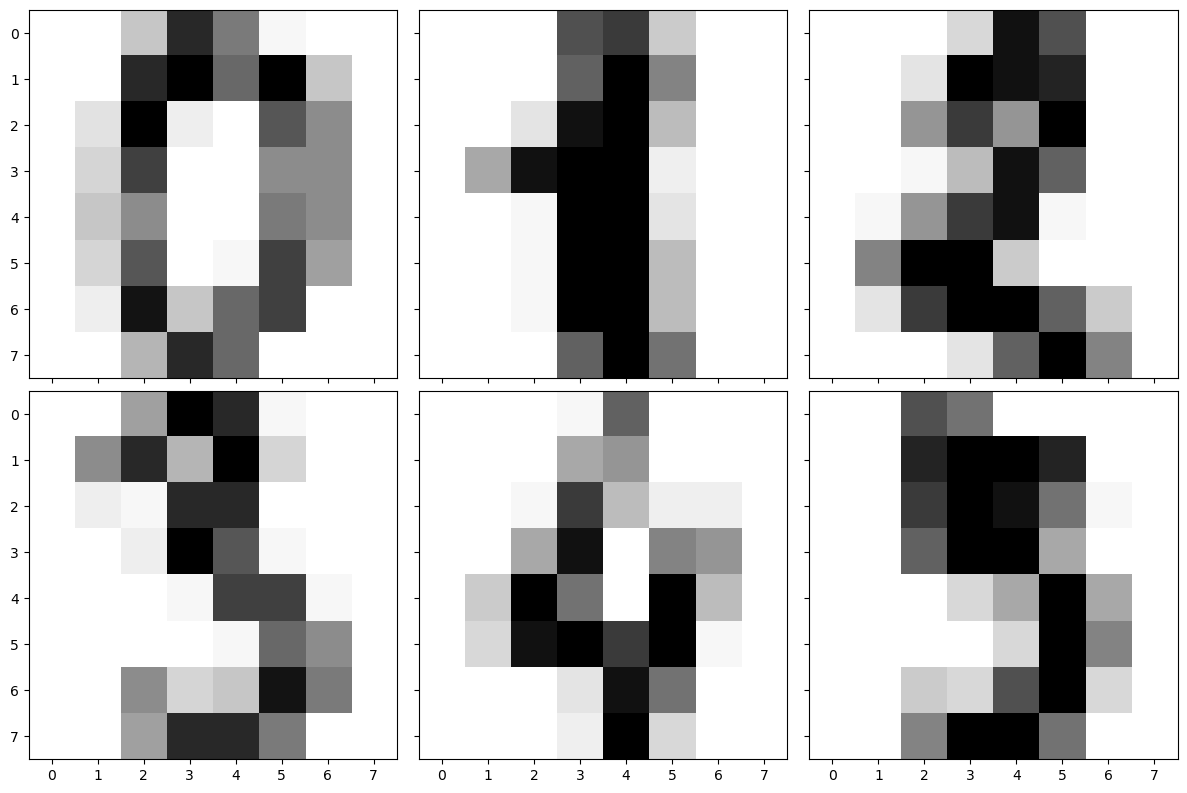

In [6]:
fig, axes = plt.subplots(nrows=2,ncols=3,sharex=True,sharey=True,figsize=(12,8))

axes[0,0].imshow(X[0].reshape(8,8),cmap='Greys')
axes[0,1].imshow(X[1].reshape(8,8),cmap='Greys')
axes[0,2].imshow(X[2].reshape(8,8),cmap='Greys')
axes[1,0].imshow(X[3].reshape(8,8),cmap='Greys')
axes[1,1].imshow(X[4].reshape(8,8),cmap='Greys')
axes[1,2].imshow(X[5].reshape(8,8),cmap='Greys')
plt.tight_layout()

##Principal Component Analysis

###2D

<Axes: xlabel='PCA1', ylabel='PCA2'>

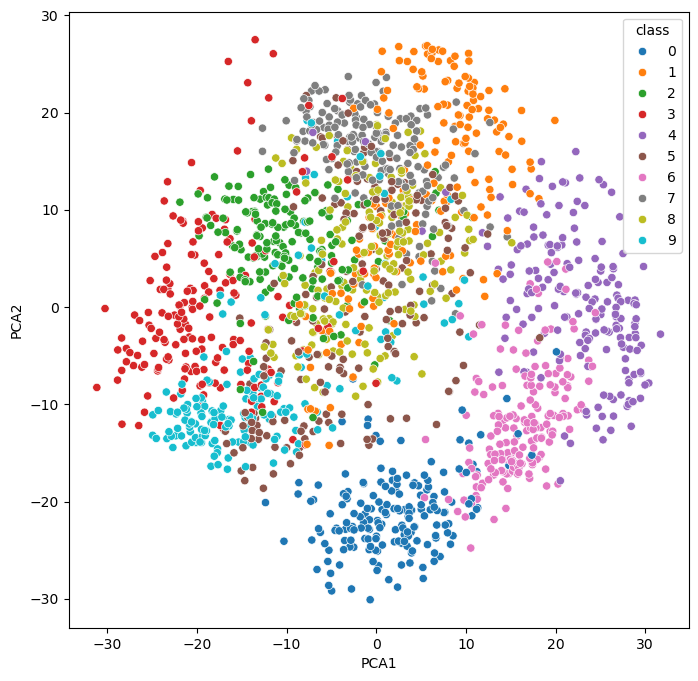

In [7]:
myPCA = PCA().fit(X)
X_pca = myPCA.transform(X) # Returns 64 columns

data = pd.DataFrame({'PCA1':X_pca[:,0],'PCA2':X_pca[:,1],'class':y})

fig = plt.figure(figsize=(8,8))
sns.scatterplot(x='PCA1',y='PCA2',hue='class',data=data,palette='tab10')

###3D

In [8]:
myPCA = PCA().fit(X)
X_pca = myPCA.transform(X) # Returns 64 columns

data = pd.DataFrame({'PCA1':X_pca[:,0],'PCA2':X_pca[:,1],'PCA3':X_pca[:,2],'class':y})

fig = px.scatter_3d(data,x='PCA1',y='PCA2',z='PCA3',color='class')
fig.show()

In [9]:
# Logistic Regression WITHOUT PCA

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
digits = load_digits()
X = digits.data
y = digits.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression model
log_reg = LogisticRegression(max_iter=5000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Predict
y_pred = log_reg.predict(X_test_scaled)

# Evaluate
accuracy_without_pca = accuracy_score(y_test, y_pred)

print("Logistic Regression WITHOUT PCA")
print("Accuracy:", round(accuracy_without_pca, 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Logistic Regression WITHOUT PCA
Accuracy: 0.9722

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.89      0.89      0.89        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.89      0.89      0.89        35
           9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360


Confusion Matrix:
 [[36  0  0  0  0  0  0  0  0  0]
 [ 0 32  0  1  1  0  0  0  2  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 3

In [10]:
# Logistic Regression WITH PCA1, PCA2, PCA3

from sklearn.decomposition import PCA
import pandas as pd

# Apply PCA with 3 components
pca = PCA(n_components=3)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Create PCA dataframe with PCA1, PCA2, PCA3
X_train_pca_df = pd.DataFrame(X_train_pca, columns=["PCA1", "PCA2", "PCA3"])
X_test_pca_df = pd.DataFrame(X_test_pca, columns=["PCA1", "PCA2", "PCA3"])

# Train Logistic Regression model on PCA features
log_reg_pca = LogisticRegression(max_iter=5000, random_state=42)
log_reg_pca.fit(X_train_pca_df, y_train)

# Predict
y_pred_pca = log_reg_pca.predict(X_test_pca_df)

# Evaluate
accuracy_with_pca = accuracy_score(y_test, y_pred_pca)

print("Logistic Regression WITH PCA1, PCA2, PCA3")
print("Accuracy:", round(accuracy_with_pca, 4))
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Captured:", round(sum(pca.explained_variance_ratio_), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_pca))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_pca))

Logistic Regression WITH PCA1, PCA2, PCA3
Accuracy: 0.6917
Explained Variance Ratio: [0.12039695 0.09662687 0.08336748]
Total Variance Captured: 0.3004

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.89      0.90        36
           1       0.55      0.64      0.59        36
           2       0.72      0.89      0.79        35
           3       0.74      0.70      0.72        37
           4       0.89      0.94      0.92        36
           5       0.41      0.24      0.31        37
           6       0.92      0.94      0.93        36
           7       0.74      0.69      0.71        36
           8       0.41      0.34      0.38        35
           9       0.51      0.64      0.57        36

    accuracy                           0.69       360
   macro avg       0.68      0.69      0.68       360
weighted avg       0.68      0.69      0.68       360


Confusion Matrix:
 [[32  0  0  0  1  0  1  0  0  2]
 [ 2 23  5 

In [11]:
# Compare results

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression without PCA",
        "Logistic Regression with PCA1, PCA2, PCA3"
    ],
    "Accuracy": [
        accuracy_without_pca,
        accuracy_with_pca
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression without PCA,0.972222
1,"Logistic Regression with PCA1, PCA2, PCA3",0.691667


## PCA component comparison

In [14]:
# Importing required libraries
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

# Creating an empty list to store PCA experiment results
pca_results = []

# To test Logistic Regression performance using different numbers of PCA components
# Lower components = more dimensionality reduction, but may lose important information
# Higher components = more information retained, but less compression
for n in [3, 4, 5, 10, 20, 30, 40, 50, 64]:
    
    # Create a PCA object with n principal components
    pca = PCA(n_components=n)
    
    # Fit PCA on the scaled training data and transform it
    # fit_transform learns PCA directions from training data only
    X_train_pca = pca.fit_transform(X_train_scaled)
    
    # Transform test data using the same PCA directions learned from training data
    # We do NOT fit PCA again on test data to avoid data leakage
    X_test_pca = pca.transform(X_test_scaled)
    
    # Create a Logistic Regression model
    model = LogisticRegression(max_iter=5000, random_state=42)
    
    # Train the model using PCA-transformed training data
    model.fit(X_train_pca, y_train)
    
    # Predict digit labels on PCA-transformed test data
    y_pred = model.predict(X_test_pca)
    
    # Store the number of PCA components, variance captured, and model accuracy
    pca_results.append({
        "PCA Components": n,
        "Variance Captured": round(pca.explained_variance_ratio_.sum(), 4),
        "Accuracy": round(accuracy_score(y_test, y_pred), 4)
    })

# Convert results into a DataFrame for easy comparison
pca_comparison = pd.DataFrame(pca_results)

# Display comparison table
pca_comparison


,PCA Components,Variance Captured,Accuracy
0,3,0.3004,0.6917
1,4,0.3672,0.7889
2,5,0.4162,0.8056
3,10,0.5898,0.8778
4,20,0.7899,0.9417
5,30,0.8933,0.9556
6,40,0.9516,0.9528
7,50,0.9833,0.9667
8,64,1.0000,0.9722
